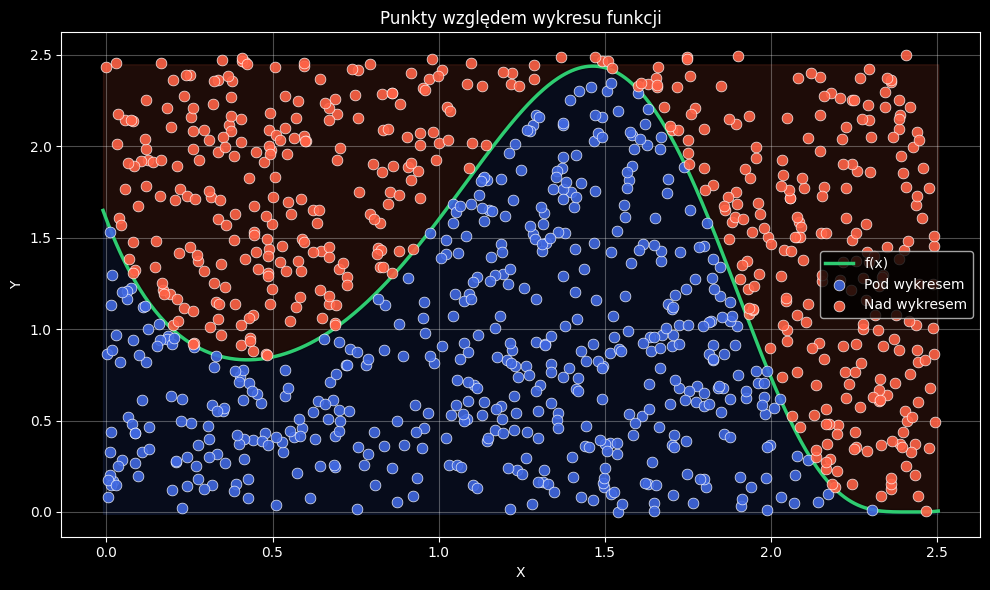

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Zdefiniuj swoją funkcję
def f(x):
    return (( (x-1)**3 - np.sqrt( 3*x + 1))**4) / 10  # ← zmień na swoją funkcję

# 2. Wczytaj punkty z pliku TXT (format: X\tY)
data = np.loadtxt("POINTS.txt", delimiter='\t')
x_pts, y_pts = data[:, 0], data[:, 1]

# 3. Określ czy punkt jest pod wykresem
y_func = f(x_pts)
pod_wykresem = y_pts < y_func

# 4. Rysuj
x_line = np.linspace(x_pts.min() - 0.01, x_pts.max() + 0.01, 500)
y_line = f(x_line)

fig, ax = plt.subplots(figsize=(10, 6))

# === WYPEŁNIENIE pod/nad krzywą ===
ax.fill_between(x_line, y_line, y_line.min() - 0.01,
                alpha=0.12, color='royalblue', label='_nolegend_')
ax.fill_between(x_line, y_line, y_line.max() + 0.01,
                alpha=0.12, color='tomato', label='_nolegend_')

# === LINIA FUNKCJI — pogrubiona z cieniem ===
ax.plot(x_line, y_line, color='black',   linewidth=4.5, zorder=2, alpha=0.2)  # cień
ax.plot(x_line, y_line, color='#2ecc71', linewidth=2.5, zorder=3,
        label='f(x)', linestyle='-')

# === PUNKTY ===
ax.scatter(x_pts[pod_wykresem],  y_pts[pod_wykresem],
           c='royalblue', s=60, label='Pod wykresem', zorder=5, alpha=0.9,
           edgecolors='white', linewidths=0.5)

ax.scatter(x_pts[~pod_wykresem], y_pts[~pod_wykresem],
           c='tomato', s=60, label='Nad wykresem', zorder=5, alpha=0.9,
           edgecolors='white', linewidths=0.5)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Punkty względem wykresu funkcji')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("wykres.png", dpi=150)
plt.show()